# Выпускной проект

Описание проекта: чтобы оптимизировать производственные расходы, металлургический комбинат «Стальная птица» решил уменьшить потребление электроэнергии на этапе обработки стали. Для этого комбинату нужно контролировать температуру сплава. Ваша задача — построить модель, которая будет её предсказывать.

Процесса обработки - сталь обрабатывают в металлическом ковше вместимостью 100 тонн: 
1) Расплавленную сталь заливают в ковш и подогревают до нужной температуры электродами.
2) Далее замеряют температуры и производят химический анализ;
3) Удаление серы (десульфация);
4) Циклическое легирование и корректировка:
   - температуру на несколько минут повышают,
   - добавляют легирующие материалы
   - продувают сплав инертным газом.
   - Затем его перемешивают и снова проводят измерения.
   - Такой цикл повторяется до достижения целевого химического состава и оптимальной температуры плавки.
6) Расплавленная сталь отправляется на доводку металла.

Данные состоят из нескольких файлов, полученных из разных источников:

data_arc_new.csv — Данные о нагревании металла электродами \
data_bulk_new.csv — данные о подаче сыпучих материалов (объём); \
data_wire_new.csv — данные о проволочных материалах (объём), использование всех материалов зависит от хим состава металла в ковше; \
data_bulk_time_new.csv — время подачи сыпучих материалов; \
data_wire_time_new.csv — время подачи проволочных материалах; \
data_gas_new.csv — данные о продувке сплава газом; \
data_temp_new.csv — результаты измерения температуры.

## Обзор данных

In [1]:
import os
import sys
import numpy as np
import pandas as pd

sys.path.append(os.path.abspath(os.path.join('..')))
from scr.utils import review_data, plot_distribution, plot_boxplots, plot_pairplot

In [2]:
names = ['data_arc_new', 'data_bulk_new', 'data_bulk_time_new','data_gas_new', 
         'data_temp_new', 'data_wire_new', 'data_wire_time_new']

data_arc, data_bulk, data_bulk_time, data_gas, data_temp, data_wire, data_wire_time = [
    pd.read_csv(f'../data/{name}.csv') for name in names]

**Данные об электродах**

In [3]:
review_data(data_arc)

                    Размерность: 14,876 строк x 5 столбцов

                                Пропусков нет
                              Явные дубликаты: 0

Типы данных и уникальные значения:
• key                       | тип: int64    | уник: 3,214 | пропуски:   0.0%
• Начало нагрева дугой      | тип: str      | уник: 14,876 | пропуски:   0.0%
• Конец нагрева дугой       | тип: str      | уник: 14,876 | пропуски:   0.0%
• Активная мощность         | тип: float64  | уник: 13,846 | пропуски:   0.0%
• Реактивная мощность       | тип: float64  | уник: 14,707 | пропуски:   0.0%

Статистика числовых столбцов:
                        mean|    std|     min|   [25%       50%       75%]      max|
key                 1,615.22| 934.57|    1.00| 806.00| 1,617.00| 2,429.00| 3,241.00|
Активная мощность       0.66|   0.26|    0.22|   0.47|     0.60|     0.83|     1.46|
Реактивная мощность     0.44|   5.87| -715.48|   0.34|     0.44|     0.61|     1.27|



,key,Начало нагрева дугой,Конец нагрева дугой,Активная мощность,Реактивная мощность
0,1,2019-05-03 11:02:14,2019-05-03 11:06:02,0.305130,0.211253
1,1,2019-05-03 11:07:28,2019-05-03 11:10:33,0.765658,0.477438
2,1,2019-05-03 11:11:44,2019-05-03 11:14:36,0.580313,0.430460


Всего 14 тысяч строк о итерациях нагрева металла, каждый ковш помечен уникальным ключем в `key`, количество строк key = количествам нагреваний ковша, также имеется информация о затраченных мощностях\
В столбце реактивной мощности есть аномальное отрицательное значение **-715**. \
Партий в данных 3214, а максимальный ключ 3241, какие-то партии видимо отсутсвуют. \
В данных нет пропусков и явных дубликатов. Поменяем тип столбцов с датой на временной.

In [4]:
data_arc.columns = ['key', 'start', 'end', 'activ', 'react']

data_arc[['start', 'end']] = data_arc[['start', 'end']].apply(pd.to_datetime)

**Данные о подаче сыпучих материалов**

In [5]:
review_data(data_bulk)

                    Размерность: 3,129 строк x 16 столбцов

                     Количество столбцов с пропусками: 15
                              Явные дубликаты: 0

Типы данных и уникальные значения:
• key                       | тип: int64    | уник: 3,129 | пропуски:   0.0%
• Bulk 1                    | тип: float64  | уник:    47 | пропуски:  92.0%
• Bulk 2                    | тип: float64  | уник:    15 | пропуски:  99.3%
• Bulk 3                    | тип: float64  | уник:   278 | пропуски:  58.5%
• Bulk 4                    | тип: float64  | уник:   206 | пропуски:  67.6%
• Bulk 5                    | тип: float64  | уник:    55 | пропуски:  97.5%
• Bulk 6                    | тип: float64  | уник:   205 | пропуски:  81.6%
• Bulk 7                    | тип: float64  | уник:    25 | пропуски:  99.2%
• Bulk 8                    | тип: float64  | уник:     1 | пропуски: 100.0%
• Bulk 9                    | тип: float64  | уник:    10 | пропуски:  99.4%
• Bulk 10                  

,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,NaN,NaN,NaN,43.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,150.0,154.0
1,2,NaN,NaN,NaN,73.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,206.0,NaN,149.0,154.0
2,3,NaN,NaN,NaN,34.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,205.0,NaN,152.0,153.0


In [6]:
empty_rows_count = data_bulk.drop(columns=['key']).isna().all(axis=1).sum()

print("Количество полностью пустых строк:", empty_rows_count)

Количество полностью пустых строк: 0


В данных очень много пропусков, скорее всего пропуск означает неиспользование материала, тк в материалы используются по необходимости и не все сразу.

* Материалы 12, 14 и 15 используются чаще всего (меньше % пропусков), остальные не задействуются более чем в половине случаев;
* Аномальных значений нет. Bulk 12 имеет максимальное значение 1849, сильно отличается от среднего самого материала по всем данным, нужно проверить;
* В столбце key 3129 уникальных ключей, но максимальное значение 3241 - некоторые партии отсуствуют в записи;
* В данных также нет дубликатов, все типы данных верные.

Также имеется информация о времени подачи каждого материала.

In [7]:
review_data(data_bulk_time)

                    Размерность: 3,129 строк x 16 столбцов

                     Количество столбцов с пропусками: 15
                              Явные дубликаты: 0

Типы данных и уникальные значения:
• key                       | тип: int64    | уник: 3,129 | пропуски:   0.0%
• Bulk 1                    | тип: str      | уник:   252 | пропуски:  92.0%
• Bulk 2                    | тип: str      | уник:    22 | пропуски:  99.3%
• Bulk 3                    | тип: str      | уник: 1,298 | пропуски:  58.5%
• Bulk 4                    | тип: str      | уник: 1,014 | пропуски:  67.6%
• Bulk 5                    | тип: str      | уник:    77 | пропуски:  97.5%
• Bulk 6                    | тип: str      | уник:   576 | пропуски:  81.6%
• Bulk 7                    | тип: str      | уник:    25 | пропуски:  99.2%
• Bulk 8                    | тип: str      | уник:     1 | пропуски: 100.0%
• Bulk 9                    | тип: str      | уник:    19 | пропуски:  99.4%
• Bulk 10                  

,key,Bulk 1,Bulk 2,Bulk 3,Bulk 4,Bulk 5,Bulk 6,Bulk 7,Bulk 8,Bulk 9,Bulk 10,Bulk 11,Bulk 12,Bulk 13,Bulk 14,Bulk 15
0,1,NaN,NaN,NaN,2019-05-03 11:28:48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 11:24:31,NaN,2019-05-03 11:14:50,2019-05-03 11:10:43
1,2,NaN,NaN,NaN,2019-05-03 11:36:50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 11:53:30,NaN,2019-05-03 11:48:37,2019-05-03 11:44:39
2,3,NaN,NaN,NaN,2019-05-03 12:32:39,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019-05-03 12:27:13,NaN,2019-05-03 12:21:01,2019-05-03 12:16:16


Аналогичная таблица с информацией о времени подачи каждого материала. Не факт, что эта информация пригодится, тк факт использования материала уже есть в данных с объёмами;

In [8]:
data_bulk.columns = data_bulk.columns.str.lower().str.replace(' ', '_')
data_bulk_time.columns = data_bulk_time.columns.str.lower().str.replace(' ', '_')

In [9]:
for col in data_bulk_time.columns:
    if data_bulk_time[col].dtype == 'string':
        data_bulk_time[col] = pd.to_datetime(data_bulk_time[col])

**Данные о проволочных материалах**

In [10]:
review_data(data_wire)

                    Размерность: 3,081 строк x 10 столбцов

                     Количество столбцов с пропусками: 9
                              Явные дубликаты: 0

Типы данных и уникальные значения:
• key                       | тип: int64    | уник: 3,081 | пропуски:   0.0%
• Wire 1                    | тип: float64  | уник: 2,251 | пропуски:   0.8%
• Wire 2                    | тип: float64  | уник:   713 | пропуски:  65.0%
• Wire 3                    | тип: float64  | уник:    56 | пропуски:  98.0%
• Wire 4                    | тип: float64  | уник:    14 | пропуски:  99.5%
• Wire 5                    | тип: float64  | уник:     1 | пропуски: 100.0%
• Wire 6                    | тип: float64  | уник:    69 | пропуски:  97.6%
• Wire 7                    | тип: float64  | уник:    10 | пропуски:  99.6%
• Wire 8                    | тип: float64  | уник:    13 | пропуски:  99.4%
• Wire 9                    | тип: float64  | уник:    25 | пропуски:  99.1%

Статистика числовых столбцо

,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,60.059998,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,96.052315,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,91.160157,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
empty_rows_count = data_wire.drop(columns=['key']).isna().all(axis=1).sum()

print(f"Количество полностью пустых строк: {empty_rows_count}")

Количество полностью пустых строк: 0


Проволочных материалов меньше чем сыпучих, активно используется лишь первый материал, второй в 45% партий. Остальные используются очень редко, суммарно не наберётся и половины строк даже если объединять их в один признак. 

Дубликатов, выбросов и аномалий нет.

In [12]:
review_data(data_wire_time)

                    Размерность: 3,081 строк x 10 столбцов

                     Количество столбцов с пропусками: 9
                              Явные дубликаты: 0

Типы данных и уникальные значения:
• key                       | тип: int64    | уник: 3,081 | пропуски:   0.0%
• Wire 1                    | тип: str      | уник: 3,055 | пропуски:   0.8%
• Wire 2                    | тип: str      | уник: 1,079 | пропуски:  65.0%
• Wire 3                    | тип: str      | уник:    63 | пропуски:  98.0%
• Wire 4                    | тип: str      | уник:    14 | пропуски:  99.5%
• Wire 5                    | тип: str      | уник:     1 | пропуски: 100.0%
• Wire 6                    | тип: str      | уник:    73 | пропуски:  97.6%
• Wire 7                    | тип: str      | уник:    11 | пропуски:  99.6%
• Wire 8                    | тип: str      | уник:    19 | пропуски:  99.4%
• Wire 9                    | тип: str      | уник:    29 | пропуски:  99.1%

Статистика числовых столбцо

,key,Wire 1,Wire 2,Wire 3,Wire 4,Wire 5,Wire 6,Wire 7,Wire 8,Wire 9
0,1,2019-05-03 11:06:19,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2,2019-05-03 11:36:50,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3,2019-05-03 12:11:46,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Данные о времени для проволочных материалов, также имеют много пропусков, все типы данных верные, дубликатов и аномальных значений нет.

In [13]:
data_wire.columns = data_wire.columns.str.lower().str.replace(' ', '_')
data_wire_time.columns = data_wire_time.columns.str.lower().str.replace(' ', '_')

In [14]:
for col in data_wire_time.columns:
    if data_wire_time[col].dtype == 'string':
        data_wire_time[col] = pd.to_datetime(data_wire_time[col])

Аналогичная таблица о времени подачи проволочных материалов.

Интересно, что в данных меньше строк и в том числе меньше ключей - в данных о bulk 3129 строк, здесь же 3081 строка, но максимальный идентификатор тот же - 3241. Скорее всего в отстутствующих ковшах не использовался никакой материал вовсе (сыпучий или проволочный), либо некоторые партии отстствуют в данных по неизвестной причине.

**Данные о газе**

In [15]:
review_data(data_gas)

                    Размерность: 3,239 строк x 2 столбцов

                                Пропусков нет
                              Явные дубликаты: 0

Типы данных и уникальные значения:
• key                       | тип: int64    | уник: 3,239 | пропуски:   0.0%
• Газ 1                     | тип: float64  | уник: 3,239 | пропуски:   0.0%

Статистика числовых столбцов:
          mean|    std|  min|   [25%       50%       75%]      max|
key   1,621.86| 935.39| 1.00| 812.50| 1,622.00| 2,431.50| 3,241.00|
Газ 1    11.00|   6.22| 0.01|   7.04|     9.84|    13.77|    78.00|



,key,Газ 1
0,1,29.749986
1,2,12.555561
2,3,28.554793


В данных хранится суммарный объем подаваемого газа, он подается после добавления материалов, то есть количество подаваемого газа зависит от количества итераций в которых подавались материалы - чем чаще проходит цикл тем больше объем газа. Перед подачей материалов ковш нагревают, а затем остужают газом.

Нет пропусков, выбросов и аномальных значений. Газ подаётся в каждой партии.

In [16]:
data_gas.columns = ['key', 'gas']

**Данные о температуре**

In [17]:
review_data(data_temp)

                    Размерность: 18,092 строк x 3 столбцов

                     Количество столбцов с пропусками: 1
                              Явные дубликаты: 0

Типы данных и уникальные значения:
• key                       | тип: int64    | уник: 3,216 | пропуски:   0.0%
• Время замера              | тип: str      | уник: 18,092 | пропуски:   0.0%
• Температура               | тип: float64  | уник:   172 | пропуски:  18.9%

Статистика числовых столбцов:
                mean|    std|      min|     [25%       50%       75%]      max|
key         1,616.46| 934.64|     1.00|   807.75| 1,618.00| 2,429.00| 3,241.00|
Температура 1,590.72|  20.39| 1,191.00| 1,580.00| 1,590.00| 1,599.00| 1,705.00|



,key,Время замера,Температура
0,1,2019-05-03 11:02:04,1571.0
1,1,2019-05-03 11:07:18,1604.0
2,1,2019-05-03 11:11:34,1618.0


In [18]:
data_temp.columns = ['key', 'time', 'temp']
data_temp['time'] = pd.to_datetime(data_temp['time'])

И последний файл с замерами температуры металла в ковше - целевой признак задачи, в столбце 18% пропущенных данных. Постараемся выяснить причину пропуска и решим что делать с этими данными.

Температура плавления металла 1400 градусов, по этому всё партии что ниже данной температуры аномалия или брак. Видно что минимальное зачения в столбце температуры 1191, проверим сколько партий имеет температуру ниже нормальной.

**Главные особенности после обзора данных:**

* В данных отсутствуют дубликаты, все типы данных верные. Есть аномальные значения в столбце реактивной мощности и температуры (значения ниже 1400 градусов), необходимо обработать их;
* В материалах много пропусков которые говорят о том, что большинство материалов редко используются. Такие материалы лучше объединить в один признак (bulk) иначе рекие признаки будут мало полезны, либо обозначить сам факт использования, так как даже при суммировании больше половины партий будут иметь 0 в таком признаке. Точное решение можно будет принять после исследовательского и корреляционного анализа;
* Две таблицы о времени подачи материалов пока что кажутся бесполезными, так как они не отражают новой информации о материалах, можно рассмотерть продолжительность подачи материалов как признак;
* Также присутствуют пропуски в целевом признаке, нужно выяснить какие этапы замеров температур отстутвуют и если это финальные замеры удалить такие партии;
* Во всех данных отличается количество записаных партий - уникальных ключей. Нам нужны партии о которых есть вся информация.

## Предобработка

Сначала решим, что делать с пропусками в целевом признаке. Проверим в каких партиях есть пропуски

**Температура**

In [19]:
ids = data_temp.loc[data_temp['temp'].isna(), 'key'].unique()

print('Кол-во пропущенных ключей:', len(ids))
print(f'Партии с пропускам:{sorted(ids)[:5]}...')

Кол-во пропущенных ключей: 739
Партии с пропускам:[np.int64(2500), np.int64(2501), np.int64(2502), np.int64(2503), np.int64(2504)]...


In [20]:
missing = set(np.arange(ids.min(), ids.max() + 1)) - set(ids)

if missing:
    print('Отсутствуют ID:', missing)
else:
    print('Список непрерывный, пропусков нет')

Отсутствуют ID: {np.int64(3200), np.int64(2683), np.int64(3207)}


Всего 739 партий имеют пропуски в температуре (почти 23% от всех партий), по идентификатору видно, что пропуски идут подряд после 2500 ковша (за исключением 2683, 3200 и 3207 партии - их нет в данных вовсе). Рассмотрим сценарии пропусков повторяются они или нет.

In [21]:
data_temp[data_temp['key'] == 2500]

,key,time,temp
13926,2500,2019-08-10 14:04:39,1539.0
13927,2500,2019-08-10 14:13:11,NaN
13928,2500,2019-08-10 14:18:12,NaN
13929,2500,2019-08-10 14:25:53,NaN
13930,2500,2019-08-10 14:29:39,NaN


In [22]:
temp_count = data_temp.groupby('key')['temp'].count()
temp_count.loc[:2499].mean(), temp_count.loc[2500:].mean()

(np.float64(5.622123536536132), np.float64(1.0))

In [23]:
temp_count.loc[:2499][temp_count == 1]

key
195    1
279    1
Name: temp, dtype: int64

2500 ковш имеет начальный замер температуры. После 2499 партии, на каждый ковш ровно по 1 замеру температуры, когда как во всех остальных в среднем более 5 и лишь в двух партиях по одному замеру. Проверим все ли пропуски приходятся на последний замер.

Добавим номер этапа и обозначим для каждого ковша последний этап как булевое значение и посчитаем совпадения с пропусками.

In [24]:
temp = data_temp[data_temp['key'].isin(ids)].copy()
temp['stage'] = temp.groupby('key').cumcount()
temp['ismax'] = temp['stage'] == temp.groupby('key')['stage'].transform('max')

((temp['temp'].isna()) & (temp['ismax'])).sum()

np.int64(739)

Ровно 739 совпадений, следовательно в **каждом** ковше после 2499 отсутствует последний замер температуры, которой нам необходим. Мы не можем использовать эти партии при моделировании, так как в них отстутвует целевой признак.

Кроме температуры и материалов нигде пропусков не было, значит какая-то активность всё же происходила с этими партиями, но записи о последнем замере нет - возможно сбой в записи. Тк объединение данных будет происходить по ключам записей о температуре, достаточно удалить ключи в них.

In [25]:
data_temp = data_temp[~data_temp['key'].isin(ids)]

Далее проверим партии в которых температура была ниже 1400 градусов.

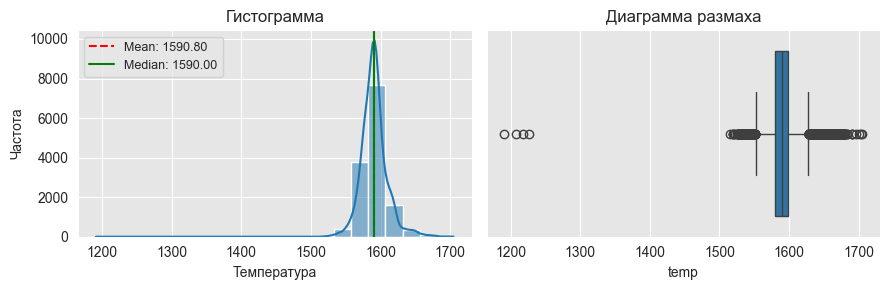

In [26]:
plot_distribution(data_temp, 'temp', 'Температура')

Видно, что в данных таких лишь 4 значения и они сильно отличаются от основного распределения если это не ошибка записи, то металл уже поступил с такой температурой. Уберём эти партии, тк температура плавления металла 1400 градусов.

In [27]:
low_temp_ids = data_temp.loc[data_temp['temp'] < 1400, 'key'].unique()
data_temp = data_temp[~data_temp['key'].isin(low_temp_ids)]
print('Количество уникальных ключей после предобработки:', data_temp['key'].nunique())

Количество уникальных ключей после предобработки: 2473


Теперь мы можем рассмотреть распределение температуры **на всех этапах**.

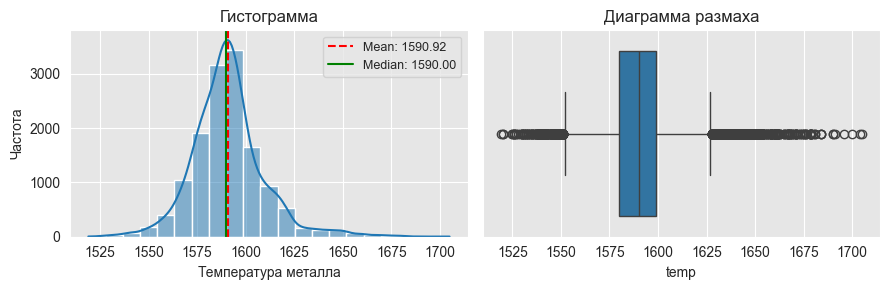

In [28]:
plot_distribution(data_temp, 'temp', 'Температура металла')

Распределение нормальное - правый хвост длиннее, есть партии которые достигают очень высоких температур. Значения начинаются с 1500 граудусов, средняя температура 1590 градусов. Это распределение температур на всех этапах, нас интересует лишь начальная и конечная температура его мы изучим после объединения данных.

**Нагревание электродами**

Проверим аномалию в столбце реактивной мощности (минимальное знечение в данных отрицательное)

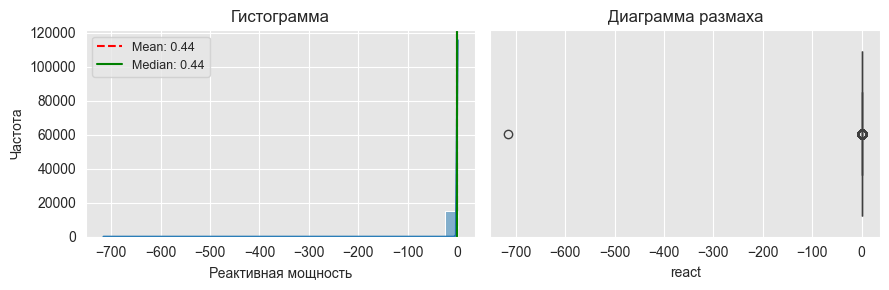

In [29]:
plot_distribution(data_arc, 'react', 'Реактивная мощность')

Лишь одна запись ниже нуля, заменим его медианной по столбцу, чтобы не удалять всю партию из-за ошибки.

In [30]:
data_arc.loc[data_arc['react'] < 0, 'react'] = data_arc['react'].median()

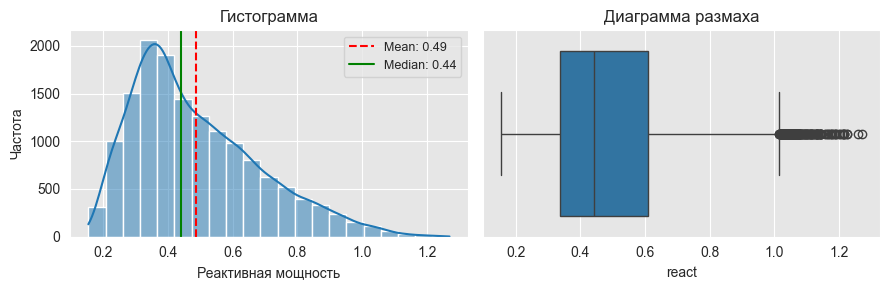

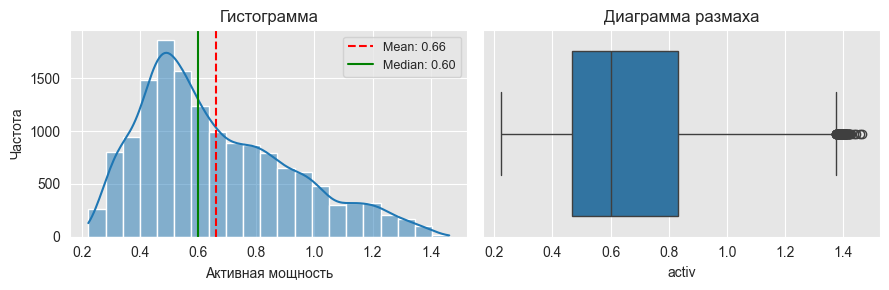

In [31]:
plot_distribution(data_arc, 'react', 'Реактивная мощность')
plot_distribution(data_arc, 'activ', 'Активная мощность')

Все аномалии обработаны. Оба распределения мощностей похожи и имеют пик значений ~0.5, на некоторых этапах мощности увеличивались до 1.2 - 1.4 единиц. Мощности на графиках представлены на всех этапах, далее мы просуммируем эти значения.

**Сыпучие материалы**

Самые частоиспользуемые материалы 12, 14 и 15й, остальные же материалы используются значительно реже: 3, 4 и 6й материалы использовались в 20-40% партий, остальные в менее чем 9% партий. Восьмой материал вовсе использовался один раз.

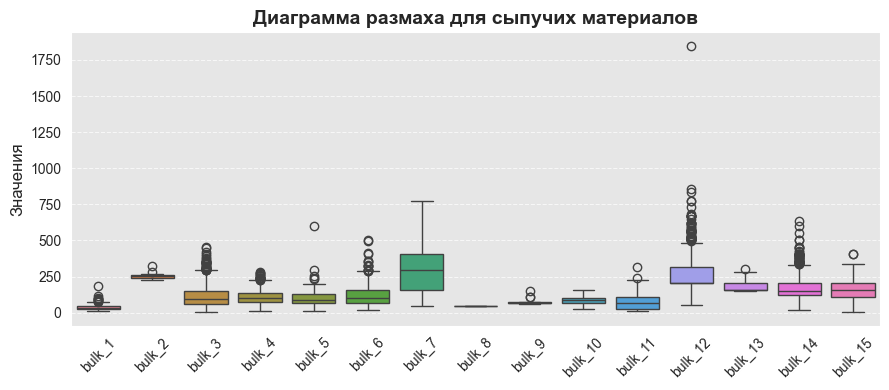

In [32]:
plot_boxplots(data_bulk, data_bulk.columns[1:], title='Диаграмма размаха для сыпучих материалов')

В среднем сыпучие материалы подаются в объеме 100-200 единиц, на диаграммах видны выбросы у большинства материалов, но они не аномальные. Больше всего выделяется 12й материал с максимальным значением 1849, в теории можно представить что материал подавался в таком объеме из-за недостатка в составе, по этому мы не будем обрабатывать его.

Редкие материалы не дадут много информации для модели и скорее будут мешать, по этому мы объедими самые редкие, оставим лишь 3 самый частых.

**Проволочные материалы**

Такая же ситуация с проволочными материалами, активно используется лишь первый, остальные не участвуют более чем в 60% партий.

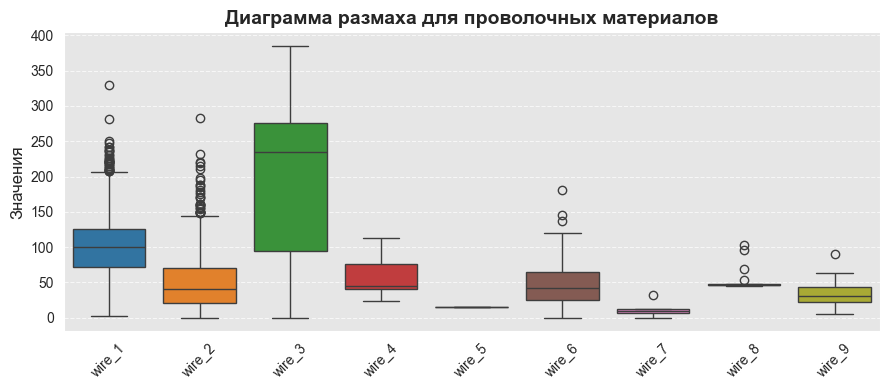

In [33]:
plot_boxplots(data_wire, data_wire.columns[1:], title='Диаграмма размаха для проволочных материалов')

Явных выбросов и аномалих в проволочных материалах нет. Первый материал используется практически всегда, в среднем подается в объеме 100 единиц, наблюдаются незначительные выбросы до 330. Второй материал используется примерно в 1/3 партий и в среднем объем меньше - около 40, также есть выбросы до 280. Остальные же проволочные материалы используются крайне редко, пятый материал использовался один раз. 

Также объеденим редкие, либо сделаем банарный признак по факту их использования.

**Газ**

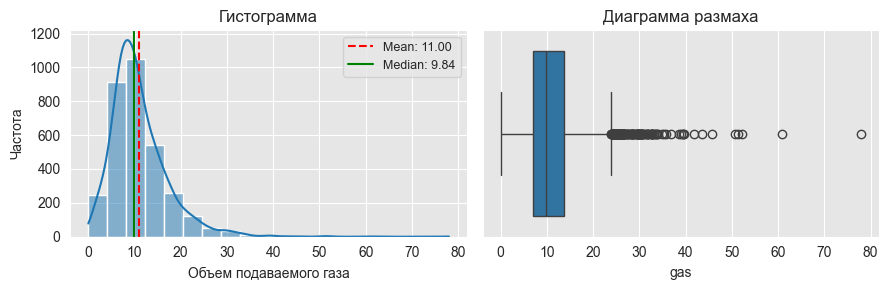

In [34]:
plot_distribution(data_gas, 'gas', 'Объем подаваемого газа')

Распределение газа имеет 1 пик около среднего и длинный хвост больших значений, большой объём газа использовался в партий с частым циклом добавления материалов.

**Итог первичной предобработки и анализа**

* Мы удалили партии с пропуском в целевом признаке, всего таких было 739 и в каждом присутствовал только первый замер температуры, поскольку важно снизить именно конечную температур мы не можем работать без неё. Скорее всего причиной пропусков является сбой в записи данных, так как пропуски идут беспрерывно во всех партиях с 2500.
* Были удалены 4 партии где была зафиксирована температура ниже 1400 градусов (ниже температуры плавления), все наблюдения были начальными;
* Обработали отрицательное значения в столбце реактивной мощности, заменили его медианной по столбце чтобы не удалять всю партию;
* Среди сыпучих и проволочных материалов лишь несколько используются наиболее часто: bulk_12, bulk_14, bulk_15 и wire_1, по остальным материалам отсутствует информация (материал не использовался) более чем в половине данных, пропуски в некоторых более 90%. Такие признаки будут вредны для модели, тк являются шумомом и представляют низкую значимость из-за малого количества данных о них. Мы объединим эти столбцы и изучить информацию о них.

Для дальнейшего анализа мы объединим все таблицы в одну агрегировав столбцы которые хранят информацию на всех этапах цикла партий.

## Объединение таблиц

Наша цель сделать 1 партия = 1 строка для прогноза конечной температуры, по этому признаки с несколькими итерациями нужно собрать в одну - мы их просуммируем.

In [35]:
#время нагрева
data_arc['heating_time'] = (data_arc['end'] - data_arc['start']).dt.total_seconds()

In [36]:
arc_features = (
    data_arc.groupby('key', as_index=False)
    .apply(
        lambda g: pd.Series({
            'activ': g['activ'].sum(),
            'react': g['react'].sum(),
            'heating_time': g['heating_time'].sum()
        })
    )
)

In [37]:
arc_features['total_power'] = np.sqrt(arc_features['activ']**2 + arc_features['react']**2)

В таблице о замерах температуры сохраним информацию о первом замере температуры (start_temp), продолжительности времени между первым и последним измерением температуры и последний замер температуры наш целевой прихнак. 

Для анализа сохраним информацию о максимальной температуре на всех этапах, чтобы исследовать что приводит к высоким температурам.

In [38]:
df = (
    data_temp.sort_values('time')
        .groupby('key')
        .agg(
            temp=('temp', 'last'),
            start_temp=('temp', 'first'),
            max_temp=('temp', 'max'),
            
            start=('time', 'first'),
            duration=('time', 'last')
        )
)

df['duration'] = (df['duration'] - df['start']).dt.total_seconds()
df = df.drop('start', axis=1)

df.reset_index(inplace=True)

**Материалы**

В материалах оставим лишь те по котороым имеются записи в большинстве партий, остальные просуммируем в other_bulk и other_wire, из таблицы о времени подчи материалов соберём время между подачей материалов в данной партии.

In [39]:
cols_to_keep = ['key', 'bulk_12', 'bulk_14', 'bulk_15', 'wire_1'] 

def process_materials(df, name, cols_to_keep):
    drop_cols = df.columns.difference(cols_to_keep)
    df[f'other_{name}'] = df[drop_cols].sum(axis=1)
    return df.drop(drop_cols, axis=1).fillna(0)

def process_time(df, name):
    min_time = df[df.columns[1:]].min(axis=1)
    max_time = df[df.columns[1:]].max(axis=1)
    df[f'{name}_time_diff'] = (max_time - min_time).dt.total_seconds()
    return df[['key', f'{name}_time_diff']]

data_bulk = process_materials(data_bulk, 'bulk', cols_to_keep)
data_bulk_time = process_time(data_bulk_time, 'bulk')

data_wire = process_materials(data_wire, 'wire', cols_to_keep)
data_wire_time = process_time(data_wire_time, 'wire')

Теперь поочердёно присоединим все данные по ключу главной таблицы о температурах (df).

In [40]:
other_tables = [arc_features, data_gas, data_bulk, data_wire, data_bulk_time, data_wire_time]

# присоединяем каждую таблицу к главному df по key
for t in other_tables:
    df = pd.merge(df, t, on='key', how='left')

In [41]:
df.isna().sum()

key                 0
temp                0
start_temp          0
max_temp            0
duration            0
activ               2
react               2
heating_time        2
total_power         2
gas                 2
bulk_12            69
bulk_14            69
bulk_15            69
other_bulk         69
wire_1            104
other_wire        104
bulk_time_diff     69
wire_time_diff    104
dtype: int64

In [42]:
empty_rows_count = df.drop(columns=['temp', 'start_temp', 'max_temp', 'duration']).isna().all(axis=1).sum()
empty_rows_bwc = df[['bulk_12', 'wire_1', 'activ']].isna().all(axis=1).sum()
empty_rows_bw = df[['bulk_12', 'wire_1']].isna().all(axis=1).sum()

print(f"Полностью пропущенно: {empty_rows_count}")
print(f"Пропущено в bulk, wire и arc совместно: {empty_rows_bwc}")
print(f"Пропущено в bulk и wire совместно: {empty_rows_bw}")

Полностью пропущенно: 0
Пропущено в bulk, wire и arc совместно: 1
Пропущено в bulk и wire совместно: 28


После объединения по ключу данных температуры в итоговом датафрейме появились пропуски, это означает что не все партии о которых есть данные о температуре есть в остальных датафреймах. Наибольшее число пропущенных ковшей в данных о проволочных материалах.

Точного объяснения не получить, по этому можно предположить теорию, что тех партий которых нет в данных о каком либо процессе, данный процесс попросту не проводился, по аналогии с пропусками в сыпучих и проволочных материалах: если материал пропущен - следовательно он не использовался, тк материалы используются по их необходимости в составе, видимо такая особенность в записи данных.

В данных о газе и электродах отсутсвуют лишь 2 партии, то есть в данном ковше не проводился нагрев электродами? В теории такое невозможно - так как замер состава происходит после подогрева металла, и даже если состав полноценный сразу это известно после нагреванния.  Отсутствие продуванеим газа в теории может быть, тк он происходить после добавления материалов.

Другая интересная особенность:

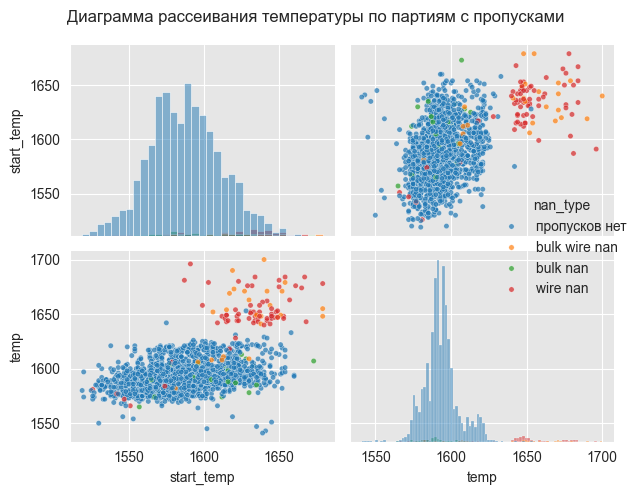

In [43]:
df['nan_type'] = 'пропусков нет' #пропусков нет

df.loc[df['bulk_12'].isna() & df['wire_1'].isna(), 'nan_type'] = 'bulk wire nan' #пропусков в bulk И wire
df.loc[df['bulk_12'].isna() & df['wire_1'].notna(), 'nan_type'] = 'bulk nan' #пропуски в bulk
df.loc[df['wire_1'].isna() & df['bulk_12'].notna(), 'nan_type'] = 'wire nan' #пропуски в wire


plot_pairplot(df[['nan_type', 'start_temp', 'temp']], hue='nan_type', 
              alpha=0.7, title='Диаграмма рассеивания температуры по партиям с пропусками')

In [44]:
df.groupby('nan_type')[['duration', 'gas']].mean().round(2)

,duration,gas
nan_type,,
bulk nan,1746.95,7.42
bulk wire nan,1626.07,6.10
wire nan,1493.09,7.74
пропусков нет,2322.38,11.38


На партии с пропущенными значениями в материалах приходятся **самые высокие значения температур** во всех данных, их явно видно на диаграмме рассеивания, они образуют отдельную группу выше основного распределения в основном состоящую из пропущенных партий в проволочных материалах, на гистограммах видно, что они в том числе попадают и в основную массу значений - нельзя утверждать что они дают только высокие температуры, но партии которые пропусков не имеют - не достигают таких температур. 

Никакой точной информации нет, но можно предположить, что раз с этими партиями проводились минимальные обработки, то и остыть металл не успевал, металл точно нагревают в начале цикла и после он не проходит те процессы за которые температура успевала упасть - средняя продолжительность обработки (duration) и объём использованного газа у таких партий ниже.

Тк по условиям для обучения нужны данные которые есть во всех датасетах, мы удалим партии с пропусками. \
Посмотрим на общую информацию об итоговом датафрейме

In [45]:
df = df.drop(columns=['nan_type']).dropna()
df.info()

<class 'pandas.DataFrame'>
Index: 2325 entries, 0 to 2472
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   key             2325 non-null   int64  
 1   temp            2325 non-null   float64
 2   start_temp      2325 non-null   float64
 3   max_temp        2325 non-null   float64
 4   duration        2325 non-null   float64
 5   activ           2325 non-null   float64
 6   react           2325 non-null   float64
 7   heating_time    2325 non-null   float64
 8   total_power     2325 non-null   float64
 9   gas             2325 non-null   float64
 10  bulk_12         2325 non-null   float64
 11  bulk_14         2325 non-null   float64
 12  bulk_15         2325 non-null   float64
 13  other_bulk      2325 non-null   float64
 14  wire_1          2325 non-null   float64
 15  other_wire      2325 non-null   float64
 16  bulk_time_diff  2325 non-null   float64
 17  wire_time_diff  2325 non-null   float64
dtypes: f

In [46]:
#df.to_csv('df_temp_prep.csv', index=False)

Итого получилось 18 признаков вместе с целевым и 2325 строк, большая часть строк пропала из-за пропусков в целевом признаке: 739, ещё 4 мы убрали из-за записей с низкой температурой, после объединения пропали ещё 148 партий.

## Промежуточный вывод

Мы провели обзор и продобработку данных. Этапы исследования:

**Пропуски и аномалии**\
В данных содержится большое количество пропусков в информации о материалах и температуре. 

Пропуски в данных о материалах означают неиспользование этих материалов. Чаще всего используют материлы: `bulk_12, bulk_14, bulk_15 и wire_1`. Остальные не используются более чем в половине случаев, их процент пропусков может достигать 99%. Такие данные будут бесполезны для обучения, они будут создавать шум и ложные взаимосвязи, мы собрали в отдельные признаки: other_bulk и other_wire;

Пропуски в данных о температуре присутствуют только после 2499 партии, пропущены все этапы кроме самого первого замера, всего пропущенно 739 партий (23%), мы не можем использовать их для обучения тк в них отсутсвует целевой признак - конечная температура;

Также мы обработали аномальные значения в температуре: ниже температуры плавления, всего таких 4 партии они были удалены. И аномально низкое значение реактивной мощности, оно было заменено на медиану, чтобы не удалять всю партию целиком.

**Разное количество партий в данных**\
Мы установили, что во всех данных отличается количество уникальных ключей. После объединения таблиц отсутствует информация о 148 партиях из разных источников, больше всего пропущенно в данных о проволочных материалах - 104 партии, сыпучих материалах - 68 (из них 28 совместно), 2 партии в данных об электродах (уникальный 1) и 2 в данных о газе.

**Неиспользование материалов даёт высокие температуры**\
Исследовав пропущенные в материалах партии мы обнаружили, что на них приходятся самые высокие температур во всём датасете, во всех остальных партих температура никогда не доходит до таких значений. В основном самые горячие партии получаются из пропусков в проволочных материалах.

Возможная причина таких температур в том, что данные партии не упевают остыть из-за отсуствия обычных этапов: металл нагревают для определения состава, когда состав удовлетворительный остальные процессы не проходят совсем либо в меньших объёмах, так они в среднем значительно меньше продуваются газом и имеют меньшую продолжительность обработки. Либо же проволочные материалы сами по себе снижают температуру ковша за счёт своих свойств или низкой изначальной температуры и его отсутствие оставляет температуру высокой.

Это самое важное наблюдение в исследовании на данный момент. \
Далее мы подготовили итоговый датасет для изучения корреляции и обучения моделей.